# Exploracion de datos y Acondicionamiento

## Carga del Dataset


In [1]:
from os import makedirs, path, system
import pandas as pd

FILE_PATH = './data/eeg_eye_state.csv'

if not path.exists(FILE_PATH):
    print("El archivo no existe localmente. Verificando dependencias...")

    try:
        from ucimlrepo import fetch_ucirepo
    except ImportError:
        print("Instalando ucimlrepo...")

        # Instalacion del paquete UCI
        from IPython import get_ipython
        if get_ipython():
            # Para notebook
            get_ipython().run_line_magic('pip', 'install ucimlrepo')
        else:
            # Para script
            system('pip install ucimlrepo')
        
        from ucimlrepo import fetch_ucirepo

    print("Iniciando descarga desde UCI Repo...")
    eeg_eye_state = fetch_ucirepo(id=264)
    df = pd.concat([eeg_eye_state.data.features, eeg_eye_state.data.targets], axis=1)
    
    # Guardar datos del dataset
    makedirs(path.dirname(FILE_PATH), exist_ok=True)
    df.to_csv(FILE_PATH, index=False)
    print(f"Datos guardados en: {FILE_PATH}")

else:
    # Los datos ya existen
    df = pd.read_csv(FILE_PATH)
    print(f"Los datos ya existen en {FILE_PATH}")

Los datos ya existen en ./data/eeg_eye_state.csv


In [2]:
FS = 128  # Frecuencia de muestreo en Hz
CHANNELS = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
TARGET_COL = 'eyeDetection' # 0: ojos abiertos, 1: ojos cerrados
df['time_sec'] = range(len(df))
df['time_sec'] = df['time_sec'] / FS
display(df.head())

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection,time_sec
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0,0.000000
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0,0.007812
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0,0.015625
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0,0.023438
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0,0.031250


## Analisis exploratorio


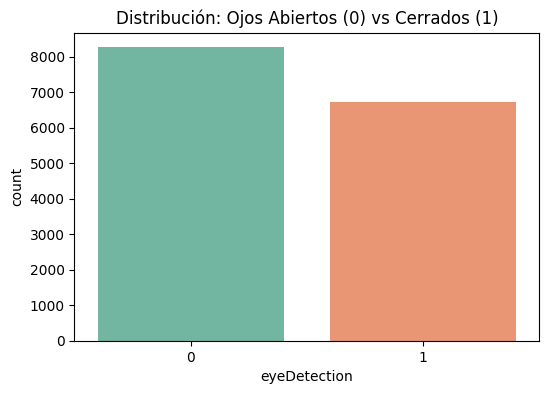

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(
    data=df,
    x=TARGET_COL,
    hue=TARGET_COL,
    palette='Set2',
    legend=False
)
plt.title('Distribución: Ojos Abiertos (0) vs Cerrados (1)')
plt.show()

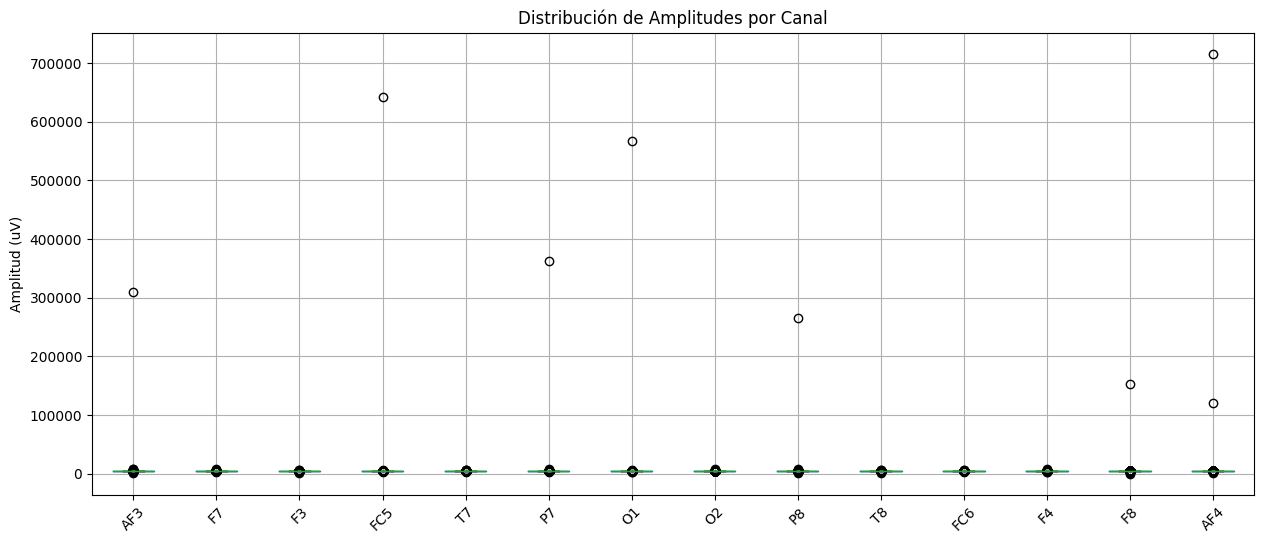

In [4]:
plt.figure(figsize=(15, 6))
df[CHANNELS].boxplot()
plt.title('Distribución de Amplitudes por Canal')
plt.ylabel('Amplitud (uV)')
plt.xticks(rotation=45)
plt.show()

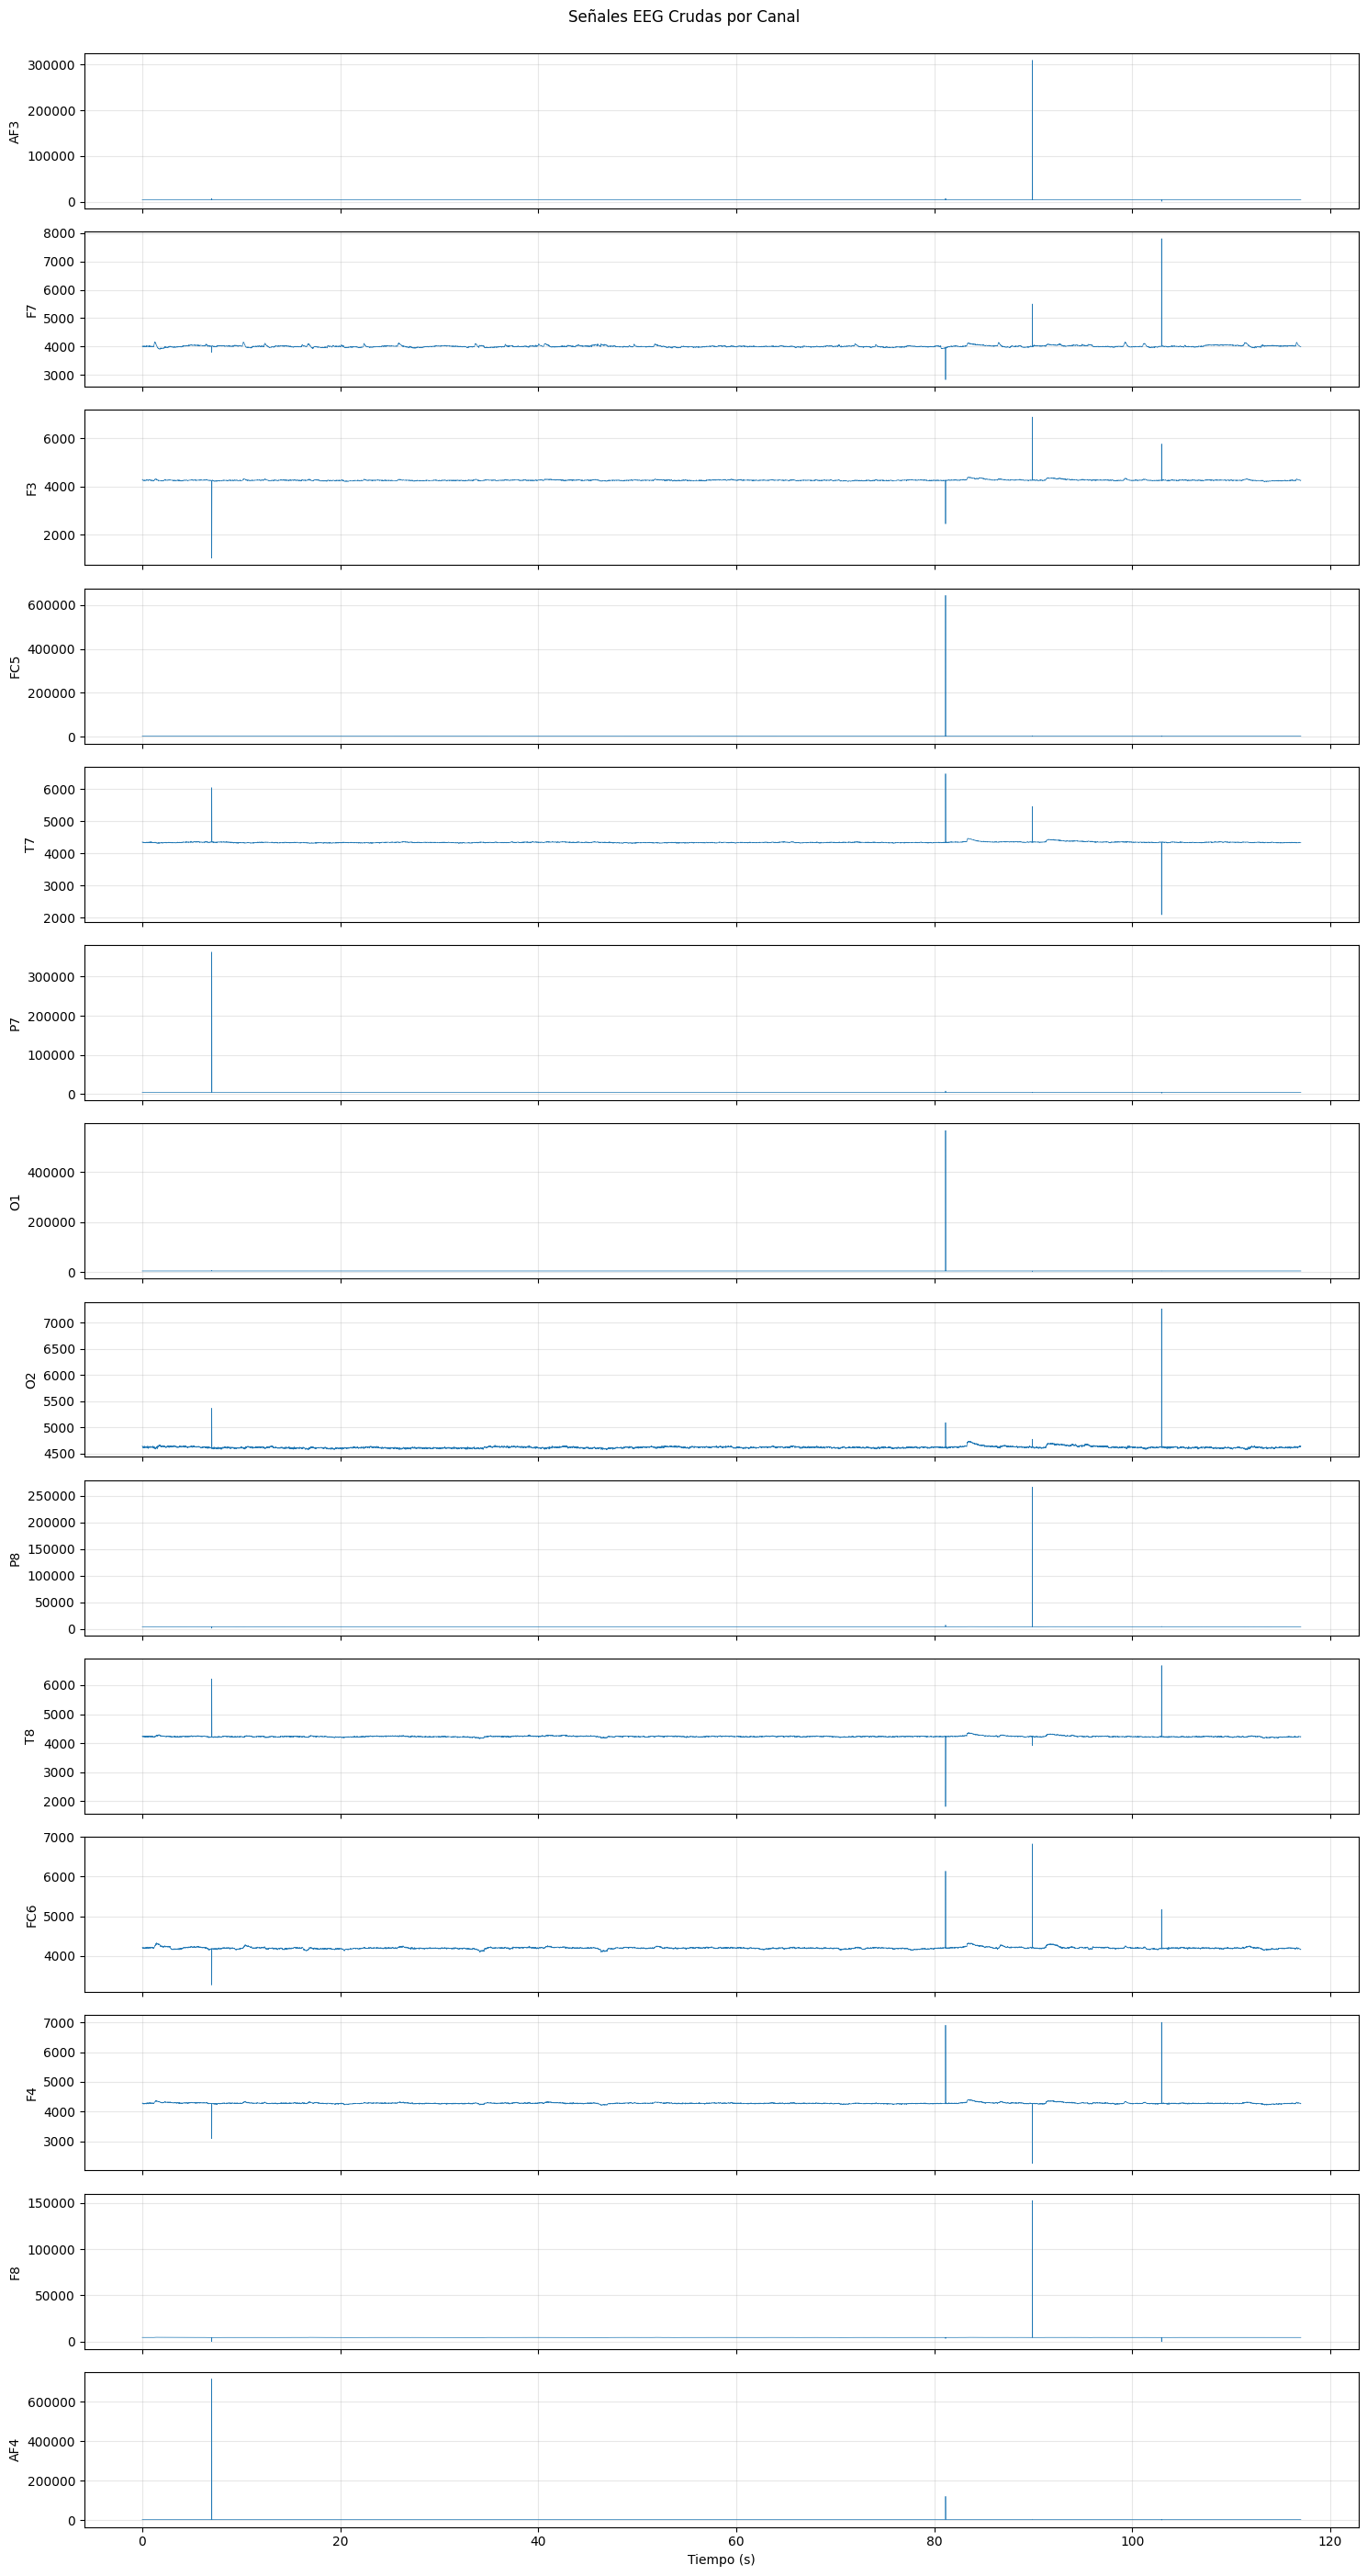

In [5]:
n_channels = len(CHANNELS)
fig, axes = plt.subplots(n_channels, 1, figsize=(15, 2 * n_channels), sharex=True)

for i, ch in enumerate(CHANNELS):
    axes[i].plot(df['time_sec'], df[ch], lw=0.5)
    axes[i].set_ylabel(ch)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Tiempo (s)')
fig.suptitle('Señales EEG Crudas por Canal', y=1)
plt.tight_layout()
plt.show()

## Acondicionamiento


### Winsorización

In [6]:
#   Limita los valores extremos de cada canal EEG reemplazando los datos
#   bajo el percentil 1 y sobre el percentil 99 por los valores de esos
#   percentiles. 

from scipy.stats.mstats import winsorize
import numpy as np

LIMITE_WIN = 0.001  # Recorta 0.10% en cada cola (percentil 1 y 99)

df_win = df.copy()

for ch in CHANNELS:
    df_win[ch] = winsorize(df[ch], limits=[LIMITE_WIN, LIMITE_WIN])

print("Winsorización aplicada")
print(f"   Límite: {LIMITE_WIN*100:.2f}% en cada cola (P{int(LIMITE_WIN*100)} y P{100-int(LIMITE_WIN*100)})")

Winsorización aplicada
   Límite: 0.10% en cada cola (P0 y P100)


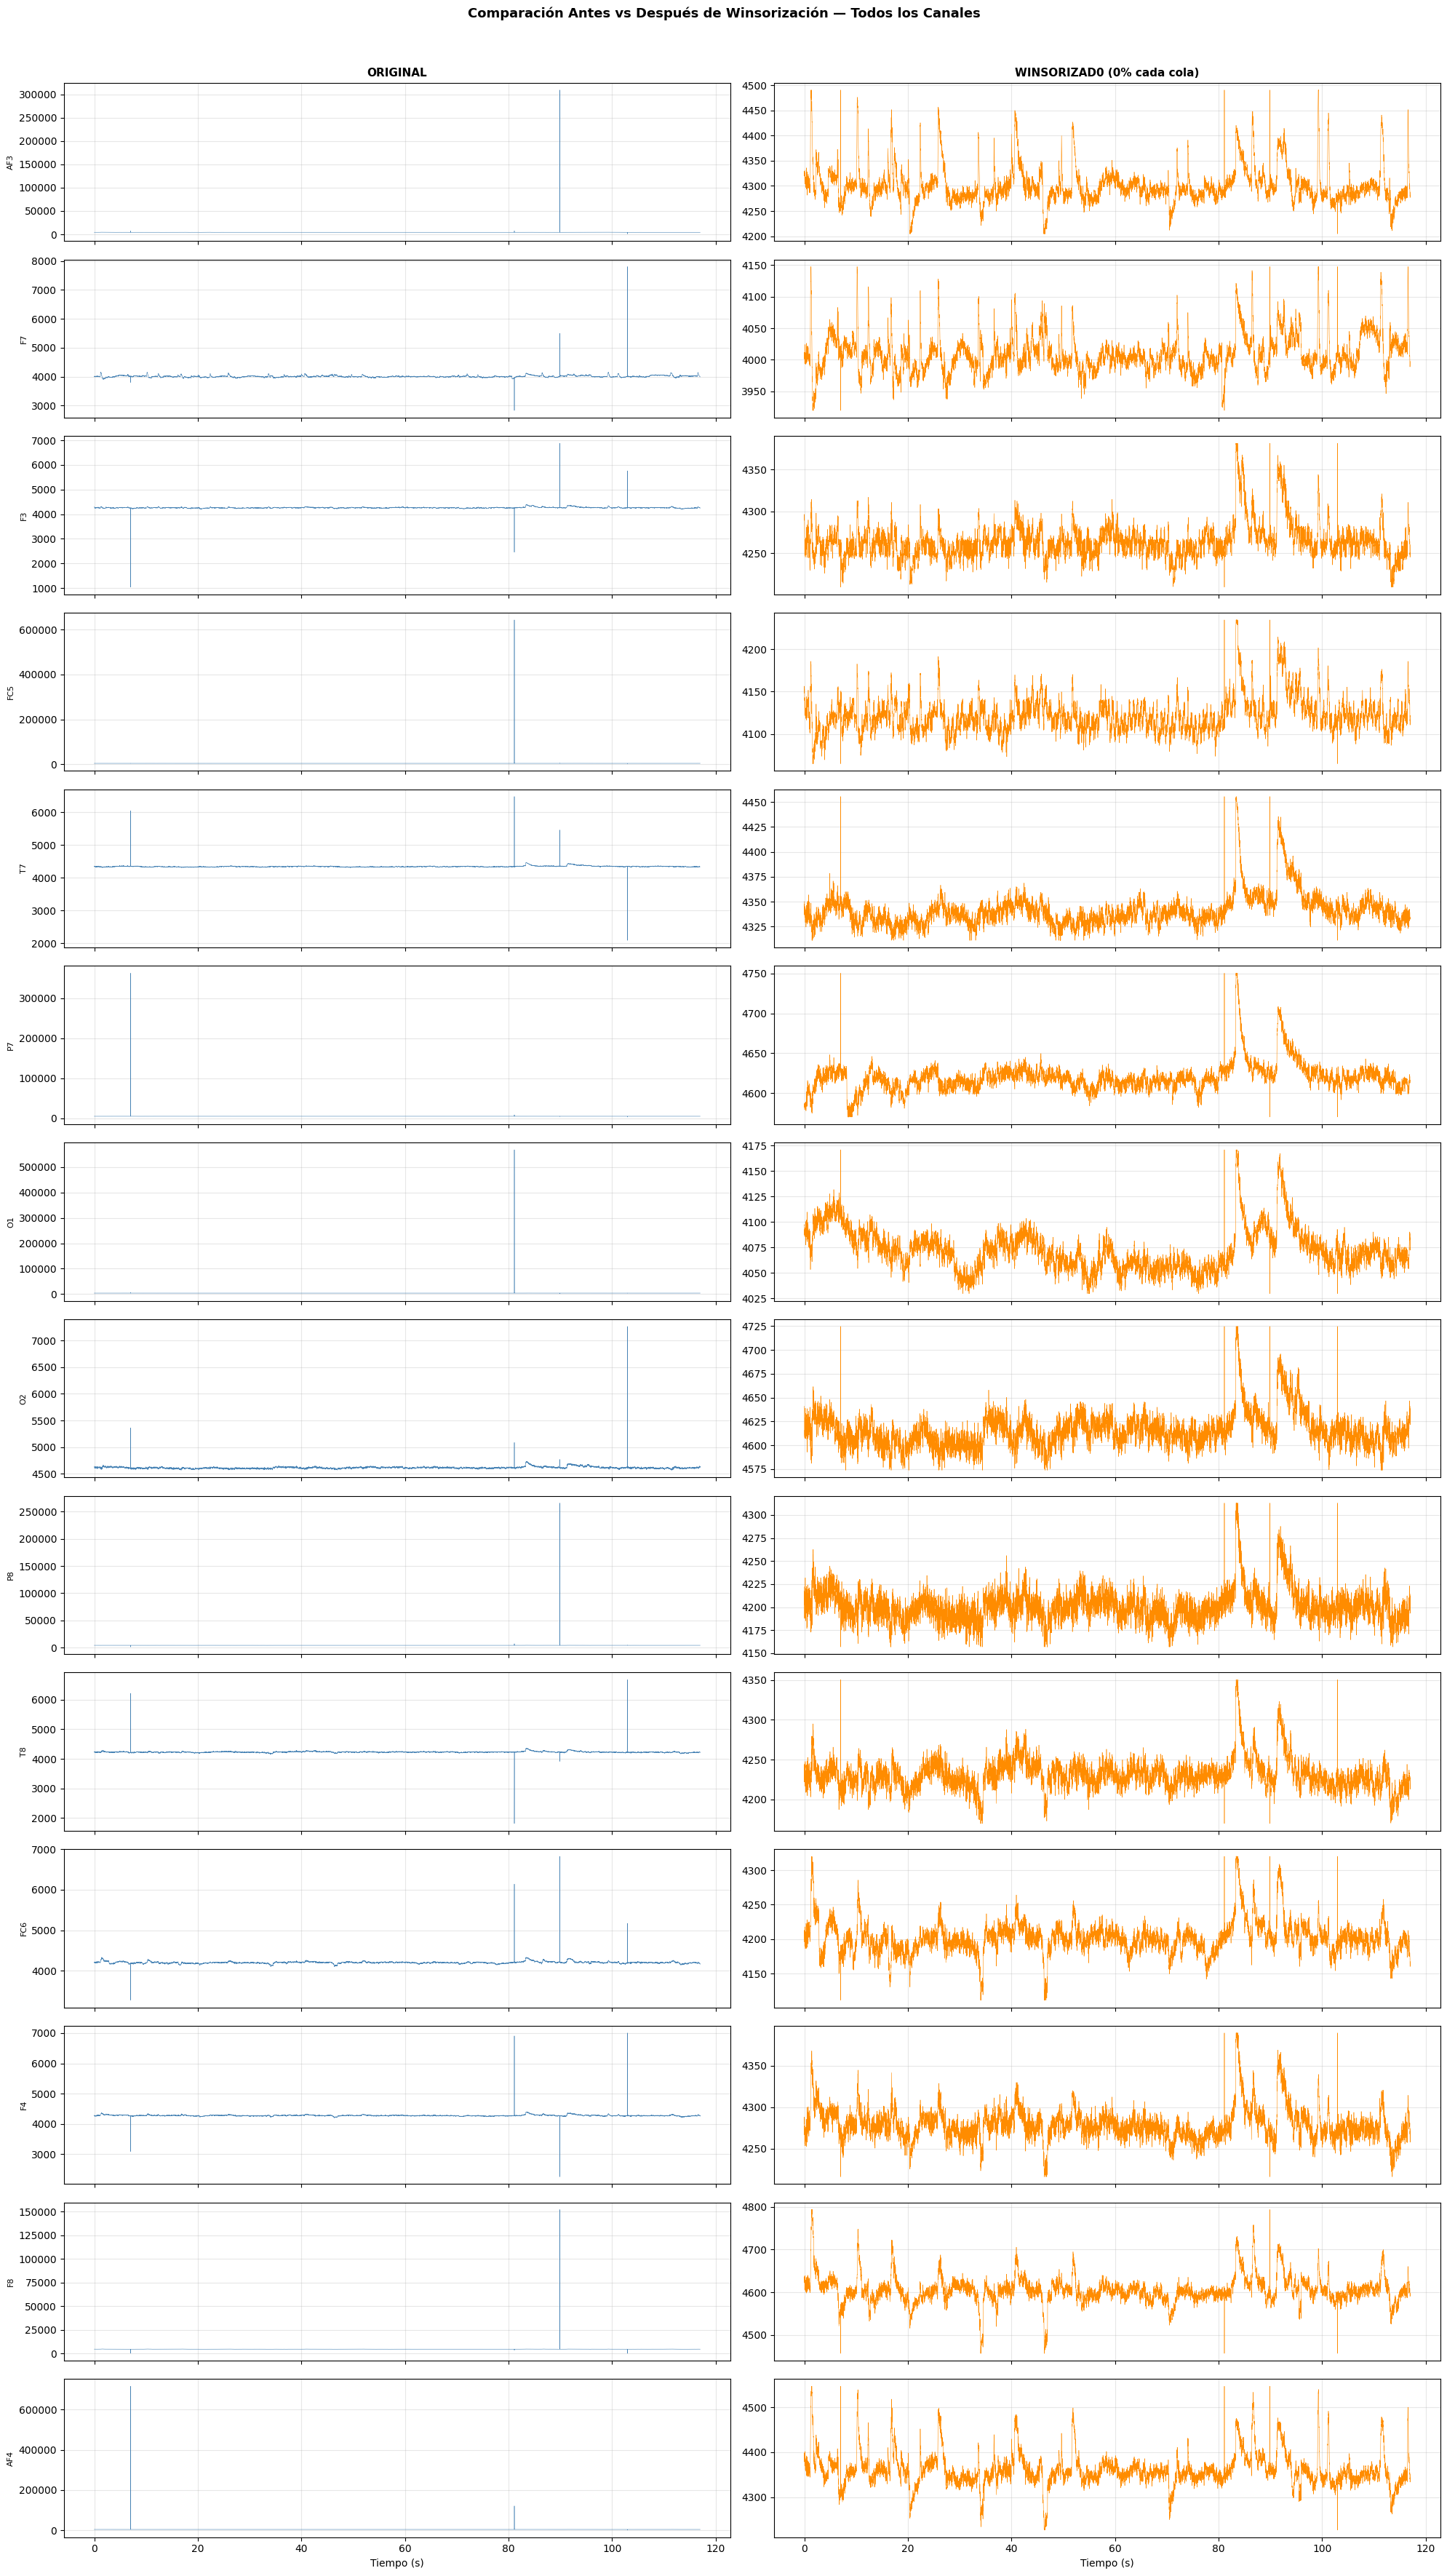

In [7]:
# Grafica los 14 canales en dos columnas — original vs winsorizad

fig, axes = plt.subplots(len(CHANNELS), 2, figsize=(20, 2.5 * len(CHANNELS)), sharex=True)

for i, ch in enumerate(CHANNELS):
    # Original
    axes[i, 0].plot(df['time_sec'], df[ch], lw=0.4, color='steelblue')
    axes[i, 0].set_ylabel(ch, fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('ORIGINAL', fontsize=11, fontweight='bold')

    # Winsorizad
    axes[i, 1].plot(df_win['time_sec'], df_win[ch], lw=0.4, color='darkorange')
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title(f'WINSORIZAD0 ({int(LIMITE_WIN*100)}% cada cola)', fontsize=11, fontweight='bold')

axes[-1, 0].set_xlabel('Tiempo (s)')
axes[-1, 1].set_xlabel('Tiempo (s)')

fig.suptitle('Comparación Antes vs Después de Winsorización — Todos los Canales', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [8]:
 #  Muestra para cada canal el mínimo y máximo antes y después de la winsorización,
 #  más el conteo de muestras que fueron efectivamente recortadas.
stats = []
for ch in CHANNELS:
    stats.append({
        'Canal': ch,
        'Min original': df[ch].min(),
        'Max original': df[ch].max(),
        'Min winsorizad': df_win[ch].min(),
        'Max winsorizad': df_win[ch].max(),
        'Outliers recortados': ((df[ch] < df_win[ch].min()) | (df[ch] > df_win[ch].max())).sum()
    })

df_stats = pd.DataFrame(stats).set_index('Canal')
display(df_stats.round(2))

,Min original,Max original,Min winsorizad,Max winsorizad,Outliers recortados
Canal,,,,,
AF3,1030.77,309231.00,4204.62,4490.77,26
F7,2830.77,7804.62,3919.49,4147.69,28
F3,1040.00,6880.51,4209.23,4381.54,26
FC5,2453.33,642564.00,4065.13,4234.36,26
T7,2089.74,6474.36,4311.28,4455.38,28
P7,2768.21,362564.00,4570.26,4750.26,20
O1,2086.15,567179.00,4029.74,4170.77,26
O2,4567.18,7264.10,4573.85,4724.62,22
P8,1357.95,265641.00,4156.92,4312.82,27


In [9]:
print(df_stats.to_string())

       Min original  Max original  Min winsorizad  Max winsorizad  Outliers recortados
Canal                                                                                 
AF3       1030.7700     309231.00         4204.62         4490.77                   26
F7        2830.7700       7804.62         3919.49         4147.69                   28
F3        1040.0000       6880.51         4209.23         4381.54                   26
FC5       2453.3300     642564.00         4065.13         4234.36                   26
T7        2089.7400       6474.36         4311.28         4455.38                   28
P7        2768.2100     362564.00         4570.26         4750.26                   20
O1        2086.1500     567179.00         4029.74         4170.77                   26
O2        4567.1800       7264.10         4573.85         4724.62                   22
P8        1357.9500     265641.00         4156.92         4312.82                   27
T8        1816.4100       6674.36         4

In [10]:
# Guardado datos winsorizados
df_clean = df_win.copy()
df_clean.to_csv("./data/eeg_eye_state_winsorized.csv", index=False)
print(" Datos guardados en ./data/eeg_eye_state_winsorized.csv")

 Datos guardados en ./data/eeg_eye_state_winsorized.csv


### Filtro pasa-banda

In [11]:
from scipy.signal import butter, filtfilt

"""
# --- Función para diseñar el filtro Butterworth pasa-bajos ---
def butter_lowpass(cutoff, fs, order=4):
    nyq = fs / 2                              # Frecuencia de Nyquist (mitad de fs)
    normal_cutoff = cutoff / nyq              # Frecuencia de corte normalizada (0 a 1)
    b, a = butter(order, normal_cutoff,       # Coeficientes del filtro
                  btype='low', analog=False)
    return b, a

CUTOFF_HZ = 40   # Frecuencia de corte en Hz (elimina todo sobre 40 Hz)
ORDER = 4        # Orden del filtro (mayor orden = corte más abrupto)

# Calcular coeficientes del filtro con los parámetros definidos
b, a = butter_lowpass(CUTOFF_HZ, FS, order=ORDER)

df_filt = df_win.copy()

# Aplicar filtro a cada canal con filtfilt (doble pasada = fase cero, sin desfase temporal)
for ch in CHANNELS:
    df_filt[ch] = filtfilt(b, a, df_win[ch])

print(f" Filtro Butterworth pasa-bajos aplicado")
print(f"   Frecuencia de corte: {CUTOFF_HZ} Hz")
print(f"   Orden: {ORDER}")
print(f"   Método: filtfilt (fase cero)")
"""

# --- Función para diseñar el filtro Butterworth pasa-bajos ---
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high],       # Coeficientes del filtro
                  btype='band', analog=False)
    return b, a

HIGHCUT_HZ = 40   # Frecuencia de corte en Hz (elimina todo sobre 40 Hz)
LOWCUT_HZ = 0.5   # Frecuencia de corte en Hz (elimina todo por debajo de 0.5 Hz)
ORDER = 4        # Orden del filtro (mayor orden = corte más abrupto)

# Calcular coeficientes del filtro con los parámetros definidos
b, a = butter_bandpass(LOWCUT_HZ, HIGHCUT_HZ, FS, order=ORDER)

df_filt = df_win.copy()

# Aplicar filtro a cada canal con filtfilt (doble pasada = fase cero, sin desfase temporal)
for ch in CHANNELS:
    df_filt[ch] = filtfilt(b, a, df_win[ch])

print(f" Filtro Butterworth pasa-banda aplicado")
print(f"   Frecuencia de corte baja: {LOWCUT_HZ} Hz")
print(f"   Frecuencia de corte alta: {HIGHCUT_HZ} Hz")
print(f"   Orden: {ORDER}")
print(f"   Método: filtfilt (fase cero)")

 Filtro Butterworth pasa-banda aplicado
   Frecuencia de corte baja: 0.5 Hz
   Frecuencia de corte alta: 40 Hz
   Orden: 4
   Método: filtfilt (fase cero)


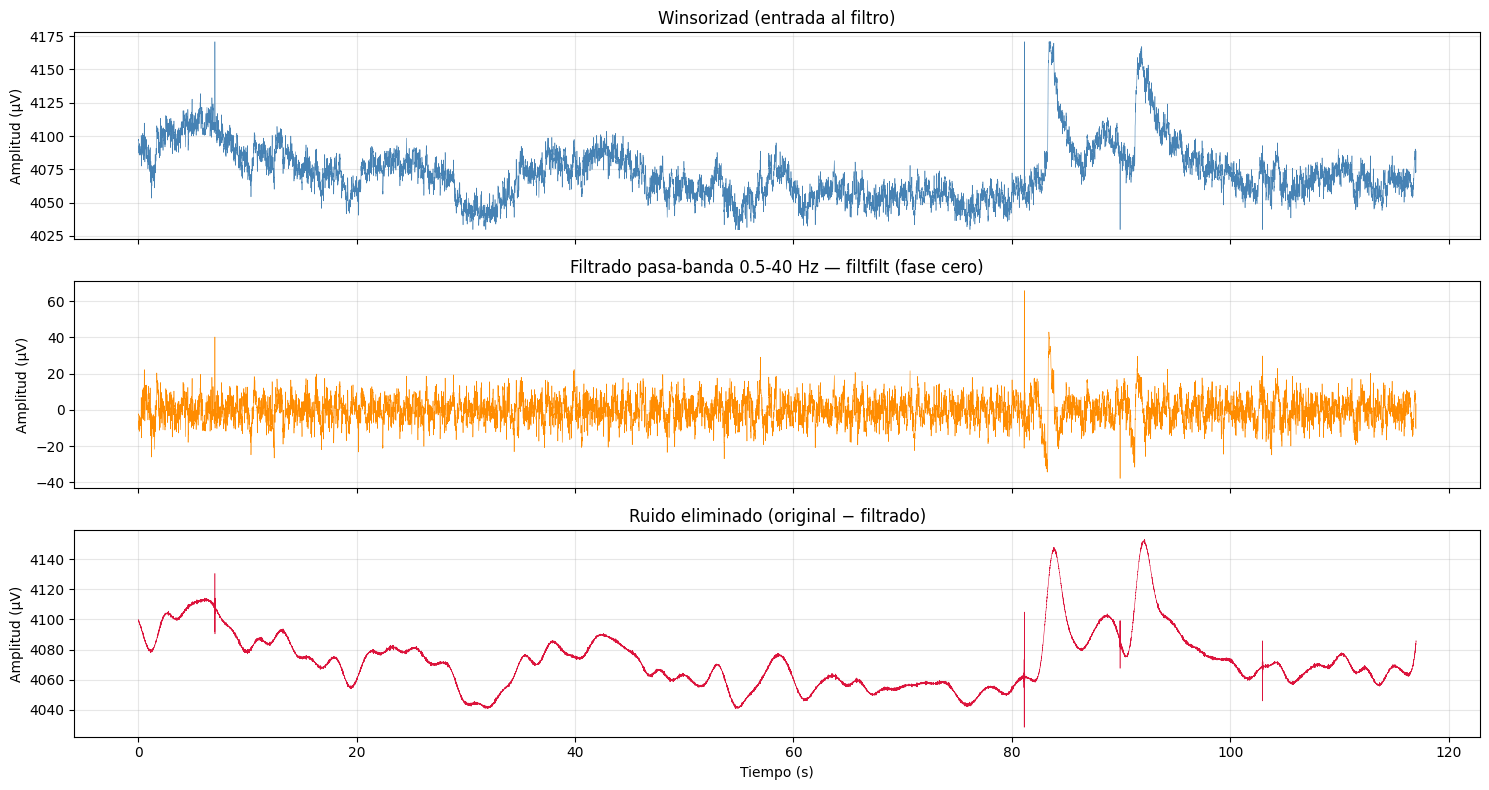

In [12]:
# Visualización filtrado (canal O1)

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

canal_ref = 'O1'

axes[0].plot(df_win['time_sec'], df_win[canal_ref], lw=0.4, color='steelblue')
axes[0].set_title('Winsorizad (entrada al filtro)')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_filt['time_sec'], df_filt[canal_ref], lw=0.4, color='darkorange')
axes[1].set_title(f'Filtrado pasa-banda {LOWCUT_HZ}-{HIGHCUT_HZ} Hz — filtfilt (fase cero)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].grid(True, alpha=0.3)

# Diferencia: lo que eliminó el filtro
diff = df_win[canal_ref].values - df_filt[canal_ref].values
axes[2].plot(df_filt['time_sec'], diff, lw=0.4, color='crimson')
axes[2].set_title('Ruido eliminado (original − filtrado)')
axes[2].set_ylabel('Amplitud (µV)')
axes[2].set_xlabel('Tiempo (s)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Normalización

In [13]:
# ============================================================
#  Normalización Z-score por canal
# ============================================================

# Z-score: resta la media y divide por la desviación estándar
# Resultado: cada canal queda con media=0 y std=1
# Se aplica por canal por separado, ya que cada electrodo
# tiene una amplitud base distinta según su ubicación

df_norm = df_filt.copy()

for ch in CHANNELS:
    media = df_filt[ch].mean()       # Media del canal
    std   = df_filt[ch].std()        # Desviación estándar del canal
    df_norm[ch] = (df_filt[ch] - media) / std  # Transformación Z-score

print("Normalización Z-score aplicada por canal")
print(f"   Media resultante  (promedio canales): {df_norm[CHANNELS].mean().mean():.6f}  → ~0")
print(f"   Std  resultante   (promedio canales): {df_norm[CHANNELS].std().mean():.6f}   → ~1")

Normalización Z-score aplicada por canal
   Media resultante  (promedio canales): 0.000000  → ~0
   Std  resultante   (promedio canales): 1.000000   → ~1


### Algunas visualizaciones

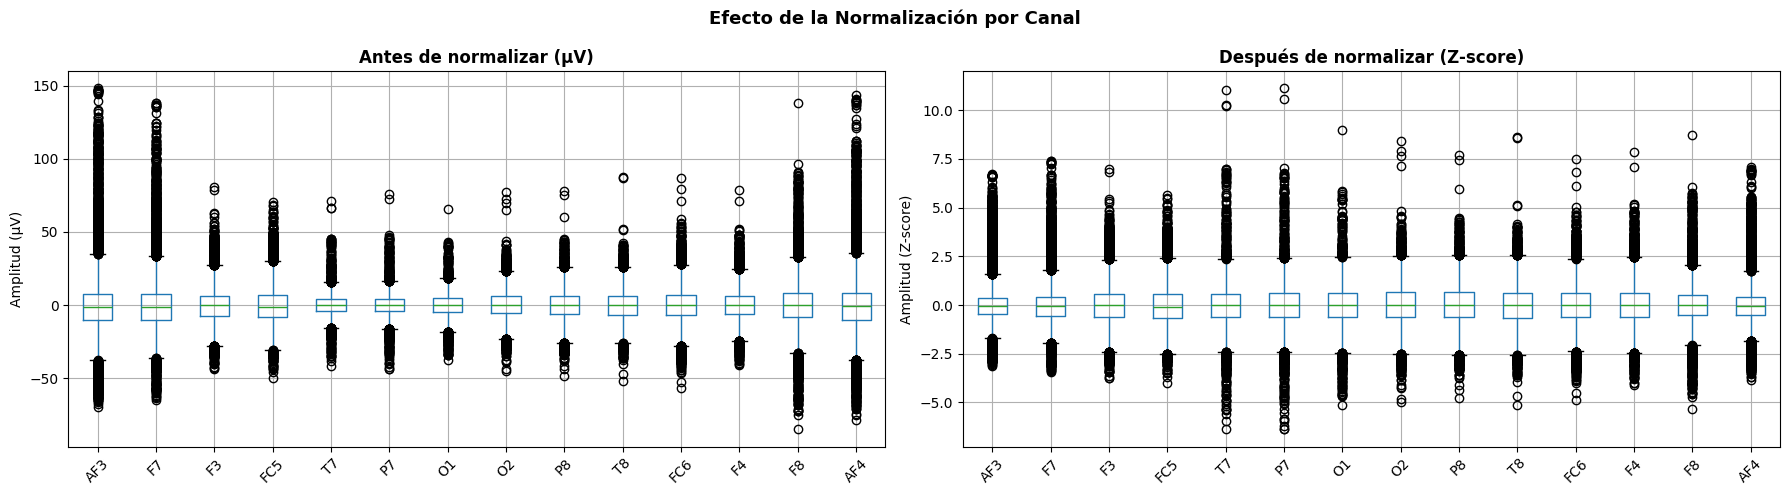

In [14]:
# ============================================================
#  Verificación: distribución antes y después
# ============================================================

# Boxplot comparativo para confirmar que todos los canales
# quedaron en la misma escala después de normalizar

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Antes: df_filt aún tiene amplitudes en µV con escala original
df_filt[CHANNELS].boxplot(ax=axes[0])
axes[0].set_title('Antes de normalizar (µV)', fontweight='bold')
axes[0].set_ylabel('Amplitud (µV)')
axes[0].tick_params(axis='x', rotation=45)

# Después: df_norm tiene todos los canales en la misma escala Z
df_norm[CHANNELS].boxplot(ax=axes[1])
axes[1].set_title('Después de normalizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Amplitud (Z-score)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Efecto de la Normalización por Canal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

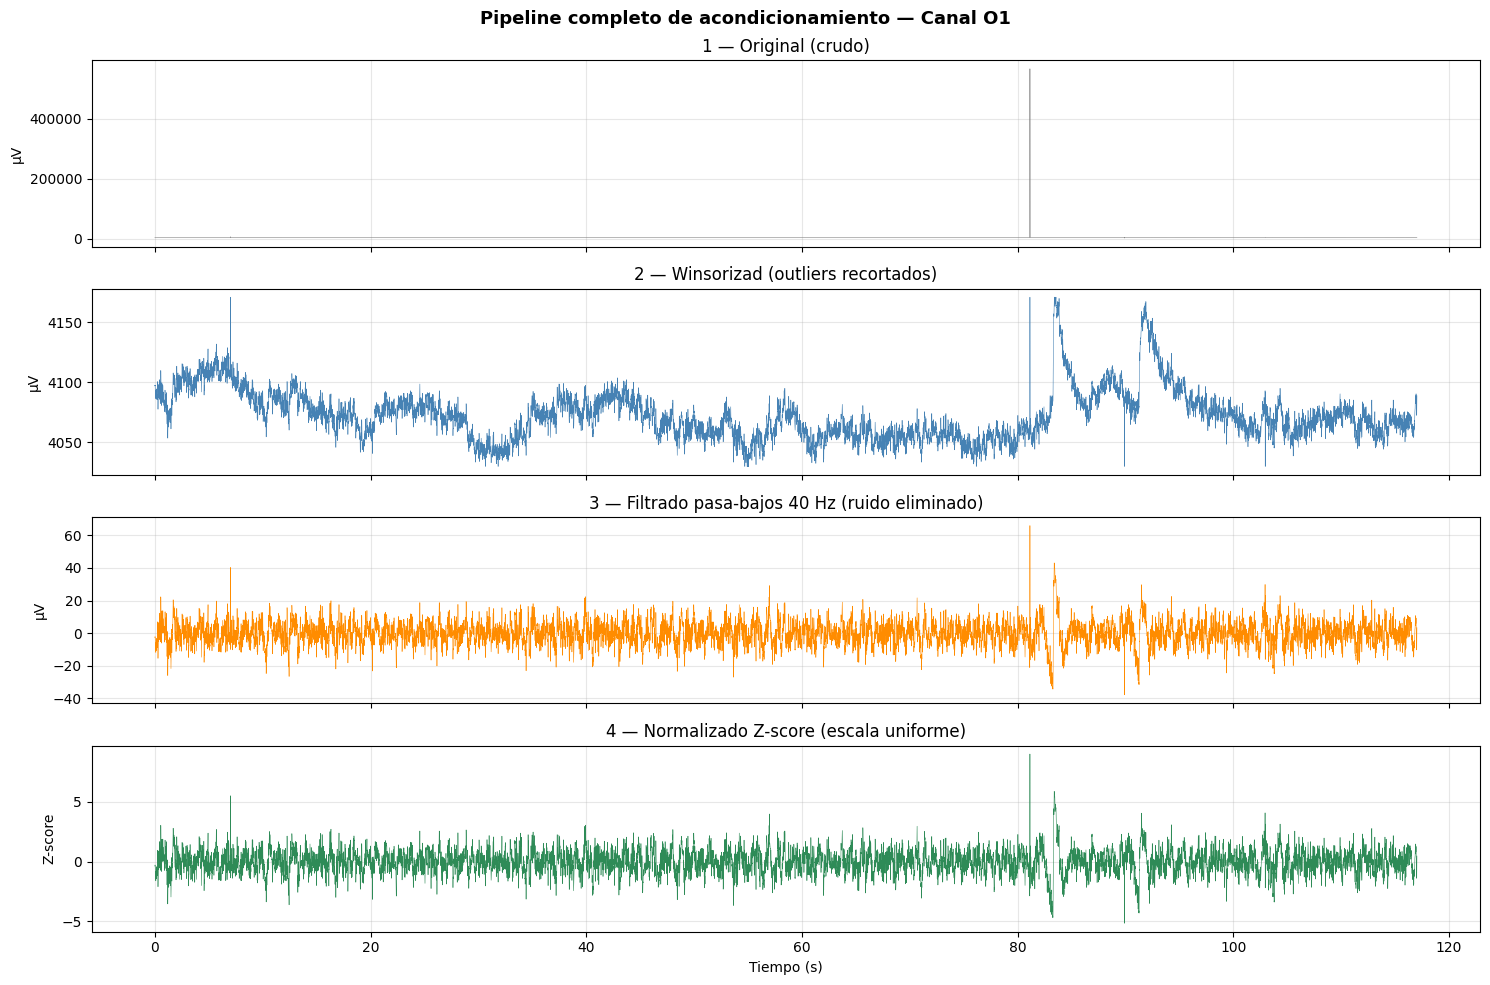

In [15]:
# ============================================================
#  Señal final: comparación completa canal O1
# ============================================================

# Muestra el pipeline completo en O1 para tener una visión
# de cómo fue evolucionando la señal en cada etapa

fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)

canal_ref = 'O1'

# Etapa 1: datos crudos originales
axes[0].plot(df['time_sec'], df[canal_ref], lw=0.4, color='gray')
axes[0].set_title('1 — Original (crudo)')
axes[0].set_ylabel('µV')
axes[0].grid(True, alpha=0.3)

# Etapa 2: después de winsorizar (picos extremos recortados)
axes[1].plot(df_win['time_sec'], df_win[canal_ref], lw=0.4, color='steelblue')
axes[1].set_title('2 — Winsorizad (outliers recortados)')
axes[1].set_ylabel('µV')
axes[1].grid(True, alpha=0.3)

# Etapa 3: después de filtrar (ruido de alta frecuencia eliminado)
axes[2].plot(df_filt['time_sec'], df_filt[canal_ref], lw=0.4, color='darkorange')
axes[2].set_title('3 — Filtrado pasa-bajos 40 Hz (ruido eliminado)')
axes[2].set_ylabel('µV')
axes[2].grid(True, alpha=0.3)

# Etapa 4: normalizado (escala Z-score, comparable entre canales)
axes[3].plot(df_norm['time_sec'], df_norm[canal_ref], lw=0.4, color='seagreen')
axes[3].set_title('4 — Normalizado Z-score (escala uniforme)')
axes[3].set_ylabel('Z-score')
axes[3].set_xlabel('Tiempo (s)')
axes[3].grid(True, alpha=0.3)

plt.suptitle(f'Pipeline completo de acondicionamiento — Canal {canal_ref}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Guardar datos

In [16]:
# ============================================================
# Guardar datos acondicionados finales
# ============================================================

# df_norm es el dataset limpio y listo para extracción de características
# Se conserva la columna time_sec y eyeDetection intactas

df_norm.to_csv("./data/eeg_eye_state_clean.csv", index=False)
print("✅ Datos acondicionados guardados en ./data/eeg_eye_state_clean.csv")
print(f"   Shape: {df_norm.shape}")
print(f"   Columnas: {list(df_norm.columns)}")

✅ Datos acondicionados guardados en ./data/eeg_eye_state_clean.csv
   Shape: (14980, 16)
   Columnas: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection', 'time_sec']
